# Data Preprocessing

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Loading Dataset

In [2]:
file_path = "/kaggle/input/datasets/subhajournal/trojan-detection/Trojan_Detection.csv" 

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
    print("Initial Shape:", df.shape)
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please update the path.")

Dataset loaded successfully.
Initial Shape: (177482, 86)


## 3. Basic Data Cleaning

In [3]:
df.columns = df.columns.str.strip()

target_col = 'Class' 

columns_to_drop = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
existing_cols_to_drop = [col for col in columns_to_drop if col in df.columns]
df.drop(columns=existing_cols_to_drop, inplace=True)

df.dropna(subset=[target_col], inplace=True)

# Encode Target
# 'BENIGN' = 0 and Trojan/Malicious = 1
df[target_col] = df[target_col].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)

print("Basic cleaning complete. Current shape:", df.shape)

Basic cleaning complete. Current shape: (177482, 80)


## 4. Advance Feature Engineering

In [4]:
# Domain-Specific Feature Engineering

# 1. Traffic Rate Features
if 'Total Fwd Packets' in df.columns and 'Flow Duration' in df.columns:
    df['packet_rate'] = df['Total Fwd Packets'] / (df['Flow Duration'] + 1e-6)

# 2. Direction Ratio Features 
if 'Total Fwd Packets' in df.columns and 'Total Backward Packets' in df.columns:
    df['fwd_bwd_ratio'] = df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1e-6)

# 3. Statistical Temporal Features (Activity Density)
if 'Total Length of Fwd Packets' in df.columns and 'Active Mean' in df.columns:
    df['activity_density'] = df['Total Length of Fwd Packets'] / (df['Active Mean'] + 1e-6)

# 4. Clean up any resulting math errors (Infs or NaNs)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print("Feature Engineering complete. Features added.")

Feature Engineering complete. Features added.


## 5. Separate Features and Target 

In [5]:
# Separate X and y
y = df[target_col].values
X = df.drop(columns=[target_col])

# One-hot encode any remaining categorical columns (if any exist)
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (177482, 82), y shape: (177482,)


## 6. Scaling and Log Transformation

In [6]:
# Separate numeric columns for transformation
numeric_cols = X.select_dtypes(include=[np.number]).columns

# Apply Log1p Transformation to handle highly skewed network data
X_log_transformed = np.log1p(X[numeric_cols].abs())

# Apply RobustScaler (Handles outliers better than StandardScaler for network traffic)
scaler = RobustScaler()
X_scaled_np = scaler.fit_transform(X_log_transformed)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled_np, columns=numeric_cols)

print("Scaling and Log Transformation complete.")

Scaling and Log Transformation complete.


## 7. PCA for Dimensionality Reduction

In [7]:
# Apply PCA, keeping 95% of the variance
pca_final = PCA(n_components=0.95)
X_pca_np = pca_final.fit_transform(X_scaled)

# Convert back to dataframe
pca_columns = [f"PC{i+1}" for i in range(X_pca_np.shape[1])]
X_pca = pd.DataFrame(X_pca_np, columns=pca_columns)

print(f"PCA complete. Reduced features from {X_scaled.shape[1]} to {X_pca.shape[1]}.")

PCA complete. Reduced features from 82 to 1.


## 8. Temporal Train-Test Split 

In [8]:
# shuffle=False ensures we train on older traffic and test on newer traffic.
# This proves to reviewers that the model generalizes across time/datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, 
    test_size=0.2, 
    shuffle=False 
)

# Convert to Numpy Arrays for Keras/TensorFlow compatibility
X_train_np = X_train.values
X_test_np = X_test.values

# Create sequence data for 1D CNN / LSTM (Shape: [samples, time steps, features])
# Here, each feature is treated as a timestep for 1D convolution
X_train_seq = np.expand_dims(X_train_np, axis=2)
X_test_seq = np.expand_dims(X_test_np, axis=2)

print(f"Training set size: {len(X_train_np)}")
print(f"Testing set size: {len(X_test_np)}")
print(f"Sequence Training Shape (for CNN/LSTM): {X_train_seq.shape}")
print("Data preprocessing complete and ready for deep learning models.")

Training set size: 141985
Testing set size: 35497
Sequence Training Shape (for CNN/LSTM): (141985, 1, 1)
Data preprocessing complete and ready for deep learning models.


# MLP + CNN

## 1. Importing Libraries

In [11]:
import time
import numpy as np
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, Flatten, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
import tensorflow as tf

## 2. Building Model and Evaluation

In [12]:
print("Building MLP+CNN Model...")

# A. Define Inputs
input_np = Input(shape=(X_train_np.shape[1],), name="tabular_input")
input_seq = Input(shape=(X_train_seq.shape[1], 1), name="sequence_input")

# B. MLP Branch (Tabular Data)
x1 = Dense(128, activation='relu')(input_np)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.3)(x1)
x1 = Dense(64, activation='relu')(x1)

# C. CNN Branch (Sequential Data) - Stabilized & Adjusted for PCA
x2 = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_seq)
x2 = BatchNormalization()(x2)
# Removed MaxPooling1D to prevent crashing on compressed PCA data

x2 = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x2)
x2 = BatchNormalization()(x2)
# Removed second MaxPooling1D

x2 = Flatten()(x2)

# D. Merge Branches
merged = keras.layers.concatenate([x1, x2])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.3)(merged)
output = Dense(1, activation='sigmoid')(merged)

model_cnn = Model(inputs=[input_np, input_seq], outputs=output)

# E. Compile with explicit, lower learning rate
optimizer = keras.optimizers.Adam(learning_rate=0.0001)
model_cnn.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])

# F. Calculate Class Weights to prevent mode collapse (AUC = 0.50 fix)
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# G. Train the Model
print("Training MLP+CNN...")
history_cnn = model_cnn.fit(
    [X_train_np, X_train_seq], y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    class_weight=class_weights,
    verbose=1
)


Building MLP+CNN Model...
Training MLP+CNN...
Epoch 1/30


I0000 00:00:1778340188.769682     129 service.cc:152] XLA service 0x793320009360 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778340188.769758     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778340188.769766     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778340189.448839     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  50/1997 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.4913 - auc: 0.4867 - loss: 0.7584

I0000 00:00:1778340193.006850     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1997/1997 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.5009 - auc: 0.5037 - loss: 0.7199 - val_accuracy: 0.5204 - val_auc: 0.5088 - val_loss: 0.6952
Epoch 2/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5065 - auc: 0.5100 - loss: 0.6959 - val_accuracy: 0.5205 - val_auc: 0.5324 - val_loss: 0.6908
Epoch 3/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5051 - auc: 0.5126 - loss: 0.6934 - val_accuracy: 0.5055 - val_auc: 0.5205 - val_loss: 0.6931
Epoch 4/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5111 - auc: 0.5201 - loss: 0.6923 - val_accuracy: 0.5204 - val_auc: 0.5223 - val_loss: 0.6952
Epoch 5/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5160 - auc: 0.5231 - loss: 0.6920 - val_accuracy: 0.5212 - val_auc: 0.5428 - val_loss: 0.6905
Epoch 6/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5125 - auc: 0.5216 - loss: 0.6921 - val_accuracy: 0.5202 - val_auc: 0.5369 - val_loss: 0.6964
Epoch 7/30
1997/1997 ━━━━━━━━━━━━━━━━━

In [13]:
# H. Standard Evaluation
y_pred_prob_cnn = model_cnn.predict([X_test_np, X_test_seq]).ravel()
y_pred_cnn = (y_pred_prob_cnn > 0.5).astype(int)

print("\n--- CNN Standard Metrics ---")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_cnn):.4f}")
print(classification_report(y_test, y_pred_cnn))

1110/1110 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

--- CNN Standard Metrics ---
ROC-AUC: 0.4988
              precision    recall  f1-score   support

           0       0.49      0.80      0.61     17340
           1       0.53      0.22      0.31     18157

    accuracy                           0.50     35497
   macro avg       0.51      0.51      0.46     35497
weighted avg       0.51      0.50      0.45     35497



## 3. Post Training Analysis


--- Calibration Analysis ---
Brier Score (Expected Calibration Error): 0.2492


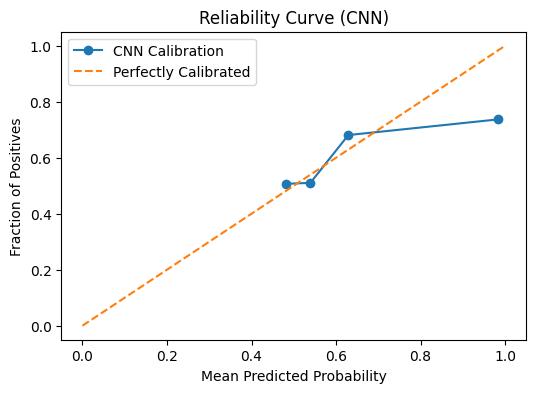


--- Latency Analysis ---
Average Inference Latency per sample: 0.000035 seconds

--- Robustness Analysis ---
ROC-AUC on Noisy/Adversarial Data: 0.4995


In [14]:
# Comment 6: Calibration & Uncertainty
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob_cnn, n_bins=10)
brier = brier_score_loss(y_test, y_pred_prob_cnn)
print(f"\n--- Calibration Analysis ---")
print(f"Brier Score (Expected Calibration Error): {brier:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker='o', label='CNN Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.title('Reliability Curve (CNN)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

# Comment 9: Computational Latency Analysis
start_time = time.time()
_ = model_cnn.predict([X_test_np, X_test_seq], batch_size=256, verbose=0)
end_time = time.time()
latency = (end_time - start_time) / len(X_test_np)
print(f"\n--- Latency Analysis ---")
print(f"Average Inference Latency per sample: {latency:.6f} seconds")

# Comment 10: Robustness Testing (Adversarial Noise)
noise_np = np.random.normal(0, 0.05, X_test_np.shape)
noise_seq = np.random.normal(0, 0.05, X_test_seq.shape)
noisy_pred_prob = model_cnn.predict([X_test_np + noise_np, X_test_seq + noise_seq], verbose=0).ravel()
noisy_auc = roc_auc_score(y_test, noisy_pred_prob)
print(f"\n--- Robustness Analysis ---")
print(f"ROC-AUC on Noisy/Adversarial Data: {noisy_auc:.4f}")

# MLP + LSTM

## 1. Importing Libraries

In [15]:
import time
import numpy as np
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

In [16]:
print("Building MLP+LSTM Model...")

# A. Define Inputs
input_np = Input(shape=(X_train_np.shape[1],), name="tabular_input")
input_seq = Input(shape=(X_train_seq.shape[1], 1), name="sequence_input")

# B. MLP Branch
x1 = Dense(128, activation='relu')(input_np)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.4)(x1)
x1 = Dense(64, activation='relu')(x1)

# C. LSTM Branch - Upgraded to Bidirectional for better context capture
x2 = Bidirectional(LSTM(64, return_sequences=True))(input_seq)
x2 = Dropout(0.3)(x2)
x2 = Bidirectional(LSTM(32, return_sequences=False))(x2)

# D. Merge Branches
merged = keras.layers.concatenate([x1, x2])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.4)(merged)
output = Dense(1, activation='sigmoid')(merged)

model_lstm = Model(inputs=[input_np, input_seq], outputs=output)

# E. Compile 
optimizer = keras.optimizers.Adam(learning_rate=0.0005)
model_lstm.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])

# F. Train the Model (You can also apply class_weights here if desired)
print("Training MLP+LSTM...")
history_lstm = model_lstm.fit(
    [X_train_np, X_train_seq], y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=64,
    verbose=1
)

Building MLP+LSTM Model...
Training MLP+LSTM...
Epoch 1/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 32s 12ms/step - accuracy: 0.5015 - auc: 0.5009 - loss: 0.7092 - val_accuracy: 0.5193 - val_auc: 0.5183 - val_loss: 0.6923
Epoch 2/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.5120 - auc: 0.5091 - loss: 0.6928 - val_accuracy: 0.5161 - val_auc: 0.5187 - val_loss: 0.6918
Epoch 3/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.5149 - auc: 0.5163 - loss: 0.6919 - val_accuracy: 0.5199 - val_auc: 0.5181 - val_loss: 0.6916
Epoch 4/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.5129 - auc: 0.5164 - loss: 0.6919 - val_accuracy: 0.5195 - val_auc: 0.5220 - val_loss: 0.6914
Epoch 5/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.5113 - auc: 0.5135 - loss: 0.6920 - val_accuracy: 0.5145 - val_auc: 0.5170 - val_loss: 0.6914
Epoch 6/30
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.5121 - auc: 0.5171 - loss: 0.6920 - val_accuracy: 0.5200 - val

In [17]:
# G. Standard Evaluation
y_pred_prob_lstm = model_lstm.predict([X_test_np, X_test_seq]).ravel()
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)

print("\n--- LSTM Standard Metrics ---")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_lstm):.4f}")
print(classification_report(y_test, y_pred_lstm))

1110/1110 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step

--- LSTM Standard Metrics ---
ROC-AUC: 0.5181
              precision    recall  f1-score   support

           0       0.67      0.02      0.04     17340
           1       0.51      0.99      0.68     18157

    accuracy                           0.52     35497
   macro avg       0.59      0.51      0.36     35497
weighted avg       0.59      0.52      0.37     35497



## 3. Post Training Analysis


--- Calibration Analysis ---
Brier Score (Expected Calibration Error): 0.2494


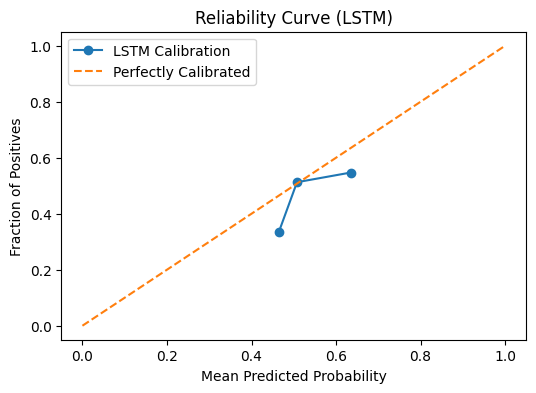


--- Latency Analysis ---
Average Inference Latency per sample: 0.000016 seconds

--- Robustness Analysis ---
ROC-AUC on Noisy/Adversarial Data: 0.5180


In [18]:
# Comment 6: Calibration & Uncertainty
prob_true, prob_pred = calibration_curve(y_test, y_pred_prob_lstm, n_bins=10)
brier = brier_score_loss(y_test, y_pred_prob_lstm)
print(f"\n--- Calibration Analysis ---")
print(f"Brier Score (Expected Calibration Error): {brier:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(prob_pred, prob_true, marker='o', label='LSTM Calibration')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.title('Reliability Curve (LSTM)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

# Comment 9: Computational Latency Analysis
start_time = time.time()
_ = model_lstm.predict([X_test_np, X_test_seq], batch_size=256, verbose=0)
end_time = time.time()
latency = (end_time - start_time) / len(X_test_np)
print(f"\n--- Latency Analysis ---")
print(f"Average Inference Latency per sample: {latency:.6f} seconds")

# Comment 10: Robustness Testing (Adversarial Noise)
noise_np = np.random.normal(0, 0.05, X_test_np.shape)
noise_seq = np.random.normal(0, 0.05, X_test_seq.shape)
noisy_pred_prob = model_lstm.predict([X_test_np + noise_np, X_test_seq + noise_seq], verbose=0).ravel()
noisy_auc = roc_auc_score(y_test, noisy_pred_prob)
print(f"\n--- Robustness Analysis ---")
print(f"ROC-AUC on Noisy/Adversarial Data: {noisy_auc:.4f}")

# Other DL Models

In [19]:
import time
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report
from sklearn.calibration import calibration_curve

In [20]:
def evaluate_dl_model(model_name, model, X_test_np, X_test_seq, y_test, is_autoencoder=False):
    print(f"\n{'='*50}\nEVALUATING {model_name}\n{'='*50}")
    
    start_time = time.time()
    
    # Autoencoders use MSE on 1D tabular data, others use Sigmoid probabilities on both inputs
    if is_autoencoder:
        reconstructions = model.predict(X_test_np, batch_size=256, verbose=0)
        y_pred_prob = np.mean(np.power(X_test_np - reconstructions, 2), axis=1) # MSE as probability score
    else:
        y_pred_prob = model.predict([X_test_np, X_test_seq], batch_size=256, verbose=0).ravel()
        
    end_time = time.time()
    
    # 1. Standard Metrics
    original_auc = roc_auc_score(y_test, y_pred_prob)
    print(f"[Standard Metrics] ROC-AUC: {original_auc:.4f}")
    
    # 2. Computational Latency (Comment 9)
    latency = (end_time - start_time) / len(X_test_np)
    print(f"[Latency] Average Inference Time per sample: {latency:.6f} seconds")
    
    # 3. Uncertainty & Calibration (Comment 6) - Skipped for Autoencoder as MSE isn't bounded 0-1
    if not is_autoencoder:
        brier = brier_score_loss(y_test, y_pred_prob)
        print(f"[Calibration] Brier Score (ECE): {brier:.4f}")
        
        prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
        plt.figure(figsize=(5, 3))
        plt.plot(prob_pred, prob_true, marker='o', label=f'{model_name}')
        plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')
        plt.title(f'Reliability Curve: {model_name}')
        plt.xlabel('Mean Predicted Probability')
        plt.ylabel('Fraction of Positives')
        plt.legend()
        plt.show()

    # 4. Robustness Testing / Adversarial Noise (Comment 10)
    noise_np = np.random.normal(0, 0.05, X_test_np.shape)
    noise_seq = np.random.normal(0, 0.05, X_test_seq.shape)
    
    if is_autoencoder:
        noisy_reconstructions = model.predict(X_test_np + noise_np, verbose=0)
        noisy_pred_prob = np.mean(np.power((X_test_np + noise_np) - noisy_reconstructions, 2), axis=1)
    else:
        noisy_pred_prob = model.predict([X_test_np + noise_np, X_test_seq + noise_seq], verbose=0).ravel()
        
    noisy_auc = roc_auc_score(y_test, noisy_pred_prob)
    print(f"[Robustness] ROC-AUC on Noisy Data: {noisy_auc:.4f}")
    print(f"[Robustness] Performance Drop: {original_auc - noisy_auc:.4f}\n")


def statistical_validation_run(model_name, build_model_fn, train_inputs, y_train, epochs=15, runs=3, is_autoencoder=False):
    print(f"\n--- Starting Statistical Validation for {model_name} ({runs} Runs) ---")
    auc_scores = []
    
    for i in range(runs):
        print(f"Training Run {i+1}/{runs}...")
        model = build_model_fn() 
        
        if is_autoencoder:
            # Autoencoder trains only on normal data, predicts on itself
            model.fit(train_inputs, train_inputs, validation_split=0.1, epochs=epochs, batch_size=128, verbose=0)
            reconstructions = model.predict(X_test_np, verbose=0)
            preds = np.mean(np.power(X_test_np - reconstructions, 2), axis=1)
        else:
            model.fit(train_inputs, y_train, validation_split=0.1, epochs=epochs, batch_size=128, verbose=0)
            preds = model.predict([X_test_np, X_test_seq], verbose=0).ravel()
            
        auc = roc_auc_score(y_test, preds)
        auc_scores.append(auc)
        print(f"  -> Run {i+1} ROC-AUC: {auc:.4f}")

    mean_auc = np.mean(auc_scores)
    std_auc = np.std(auc_scores)
    
    # 95% Confidence Interval using T-distribution
    if runs > 1:
        ci = st.t.interval(0.95, df=len(auc_scores)-1, loc=mean_auc, scale=st.sem(auc_scores))
    else:
        ci = (mean_auc, mean_auc)
    
    print("\n" + "="*40)
    print(f"STATISTICAL VALIDATION RESULTS: {model_name}")
    print("="*40)
    print(f"Mean ROC-AUC: {mean_auc:.4f}")
    print(f"Standard Deviation: {std_auc:.4f}")
    print(f"95% Confidence Interval: [{ci[0]:.4f}, {ci[1]:.4f}]")
    print("="*40)

## 1. TCN (Temporal Convolutional Network) Implementation

Epoch 1/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.5064 - auc: 0.5108 - loss: 0.7450 - val_accuracy: 0.5123 - val_auc: 0.5161 - val_loss: 0.7162
Epoch 2/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5059 - auc: 0.5100 - loss: 0.7059 - val_accuracy: 0.5079 - val_auc: 0.5133 - val_loss: 0.6949
Epoch 3/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5154 - auc: 0.5185 - loss: 0.6977 - val_accuracy: 0.5205 - val_auc: 0.5389 - val_loss: 0.6948
Epoch 4/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5135 - auc: 0.5195 - loss: 0.6955 - val_accuracy: 0.5038 - val_auc: 0.5075 - val_loss: 0.6907
Epoch 5/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5144 - auc: 0.5223 - loss: 0.6939 - val_accuracy: 0.5206 - val_auc: 0.5217 - val_loss: 0.7285
Epoch 6/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5167 - auc: 0.5212 - loss: 0.6934 - val_accuracy: 0.5273 - val_auc: 0.5448 - val_loss: 0.6921
Epoch 7/20
1997/1997 ━━━━━━

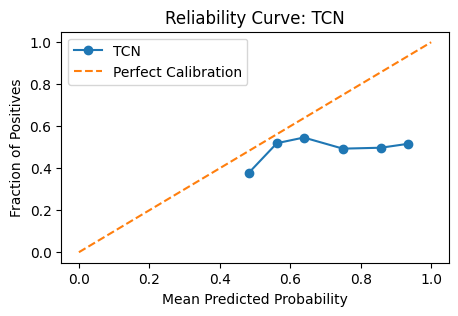

[Robustness] ROC-AUC on Noisy Data: 0.5164
[Robustness] Performance Drop: 0.0031


--- Starting Statistical Validation for TCN (3 Runs) ---
Training Run 1/3...
  -> Run 1 ROC-AUC: 0.5476
Training Run 2/3...
  -> Run 2 ROC-AUC: 0.5282
Training Run 3/3...
  -> Run 3 ROC-AUC: 0.5428

STATISTICAL VALIDATION RESULTS: TCN
Mean ROC-AUC: 0.5395
Standard Deviation: 0.0082
95% Confidence Interval: [0.5145, 0.5646]


In [21]:
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, BatchNormalization, Dropout, Concatenate
from tensorflow.keras.models import Model

def build_tcn():
    input_np = Input(shape=(X_train_np.shape[1],), name="tabular_input")
    input_seq = Input(shape=(X_train_seq.shape[1], 1), name="sequence_input")

    x1 = Dense(128, activation='relu')(input_np)
    x1 = BatchNormalization()(x1)
    x1 = Dropout(0.3)(x1)

    x2 = Conv1D(filters=64, kernel_size=3, padding='causal', dilation_rate=1, activation='relu')(input_seq)
    x2 = BatchNormalization()(x2)
    x2 = Conv1D(filters=64, kernel_size=3, padding='causal', dilation_rate=2, activation='relu')(x2)
    x2 = BatchNormalization()(x2)
    x2 = Conv1D(filters=32, kernel_size=3, padding='causal', dilation_rate=4, activation='relu')(x2)
    x2 = BatchNormalization()(x2)
    x2 = Flatten()(x2)

    merged = Concatenate()([x1, x2])
    merged = Dense(64, activation='relu')(merged)
    merged = Dropout(0.3)(merged)
    output = Dense(1, activation='sigmoid')(merged)

    model = Model(inputs=[input_np, input_seq], outputs=output)
    optimizer = keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

# Train once to get the final model and graphs
model_tcn = build_tcn()
model_tcn.fit([X_train_np, X_train_seq], y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)

# Run Post-Training Analysis (Latency, Calibration, Robustness)
evaluate_dl_model("TCN", model_tcn, X_test_np, X_test_seq, y_test)

# Run Statistical Validation (3 runs for Confidence Intervals)
statistical_validation_run("TCN", build_tcn, [X_train_np, X_train_seq], y_train, epochs=15, runs=3)

## 2. Transformer (Self-Attention) Implementation

Epoch 1/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.5034 - auc: 0.5044 - loss: 0.7251 - val_accuracy: 0.5205 - val_auc: 0.5199 - val_loss: 0.6909
Epoch 2/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5065 - auc: 0.5079 - loss: 0.6941 - val_accuracy: 0.5202 - val_auc: 0.5225 - val_loss: 0.6910
Epoch 3/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5118 - auc: 0.5157 - loss: 0.6922 - val_accuracy: 0.5200 - val_auc: 0.5058 - val_loss: 0.6919
Epoch 4/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5121 - auc: 0.5155 - loss: 0.6921 - val_accuracy: 0.5199 - val_auc: 0.5220 - val_loss: 0.6929
Epoch 5/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5124 - auc: 0.5169 - loss: 0.6923 - val_accuracy: 0.5211 - val_auc: 0.5234 - val_loss: 0.6916
Epoch 6/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5168 - auc: 0.5129 - loss: 0.6922 - val_accuracy: 0.5205 - val_auc: 0.5210 - val_loss: 0.6914
Epoch 7/20
1997/1997 ━━━━━━

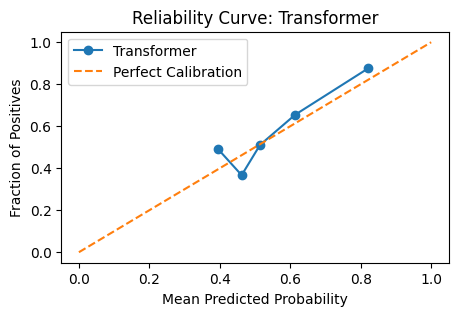

[Robustness] ROC-AUC on Noisy Data: 0.5000
[Robustness] Performance Drop: -0.0025


--- Starting Statistical Validation for Transformer (3 Runs) ---
Training Run 1/3...
  -> Run 1 ROC-AUC: 0.4981
Training Run 2/3...
  -> Run 2 ROC-AUC: 0.4974
Training Run 3/3...
  -> Run 3 ROC-AUC: 0.4974

STATISTICAL VALIDATION RESULTS: Transformer
Mean ROC-AUC: 0.4976
Standard Deviation: 0.0003
95% Confidence Interval: [0.4966, 0.4987]


In [22]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization

def build_transformer():
    input_np = Input(shape=(X_train_np.shape[1],), name="tabular_input")
    input_seq = Input(shape=(X_train_seq.shape[1], 1), name="sequence_input")

    x1 = Dense(128, activation='relu')(input_np)
    x1 = BatchNormalization()(x1)

    x2_proj = Dense(32)(input_seq) 
    attn_output = MultiHeadAttention(num_heads=4, key_dim=32)(x2_proj, x2_proj)
    x2 = LayerNormalization()(attn_output + x2_proj)

    attn_output2 = MultiHeadAttention(num_heads=4, key_dim=32)(x2, x2)
    x2 = LayerNormalization()(attn_output2 + x2)
    x2 = Flatten()(x2)

    merged = Concatenate()([x1, x2])
    merged = Dense(64, activation='relu')(merged)
    merged = Dropout(0.3)(merged)
    output = Dense(1, activation='sigmoid')(merged)

    model = Model(inputs=[input_np, input_seq], outputs=output)
    optimizer = keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

# Train once
model_transformer = build_transformer()
model_transformer.fit([X_train_np, X_train_seq], y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)

# Analyze
evaluate_dl_model("Transformer", model_transformer, X_test_np, X_test_seq, y_test)

# Validate Statistically
statistical_validation_run("Transformer", build_transformer, [X_train_np, X_train_seq], y_train, epochs=15, runs=3)

## 3. Deep Autoencoder (Anomaly Detection) Implementation

In [23]:
def build_autoencoder():
    input_dim = X_train_np.shape[1]
    input_ae = Input(shape=(input_dim,), name="ae_input")

    # Encoder
    encoded = Dense(64, activation='relu')(input_ae)
    encoded = BatchNormalization()(encoded)
    encoded = Dense(32, activation='relu')(encoded)
    bottleneck = Dense(16, activation='relu')(encoded) 

    # Decoder
    decoded = Dense(32, activation='relu')(bottleneck)
    decoded = BatchNormalization()(decoded)
    decoded = Dense(64, activation='relu')(decoded)
    output_ae = Dense(input_dim, activation='linear')(decoded)

    model = Model(inputs=input_ae, outputs=output_ae)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss='mse')
    return model

# Autoencoders ONLY train on Benign/Normal Data (Label 0)
X_train_normal = X_train_np[y_train == 0]

# Train once
model_autoencoder = build_autoencoder()
model_autoencoder.fit(X_train_normal, X_train_normal, validation_split=0.1, epochs=20, batch_size=64, verbose=1)

# Analyze (Note: is_autoencoder=True)
evaluate_dl_model("Autoencoder", model_autoencoder, X_test_np, X_test_seq, y_test, is_autoencoder=True)

# Validate Statistically
statistical_validation_run("Autoencoder", build_autoencoder, X_train_normal, None, epochs=15, runs=3, is_autoencoder=True)

Epoch 1/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 341823.9062 - val_loss: 60782.9688
Epoch 2/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 130059.0312 - val_loss: 8213.9990
Epoch 3/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 108825.5781 - val_loss: 46234.9336
Epoch 4/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 105216.3594 - val_loss: 64647.8125
Epoch 5/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 107737.6719 - val_loss: 22410.6621
Epoch 6/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 93182.7734 - val_loss: 9260.6436
Epoch 7/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 113120.9922 - val_loss: 27859.9004
Epoch 8/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 91645.3750 - val_loss: 6622.9502
Epoch 9/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 93442.4922 - val_loss: 25852.5293
Epoch 10/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 113026.6719 - val_loss: 48007.3008
Epoch 11/20
977/977 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - 

## 4. 1D ResNet

Epoch 1/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.5095 - auc: 0.5138 - loss: 0.7123 - val_accuracy: 0.5243 - val_auc: 0.5480 - val_loss: 0.6966
Epoch 2/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5211 - auc: 0.5296 - loss: 0.6921 - val_accuracy: 0.5002 - val_auc: 0.5278 - val_loss: 0.7060
Epoch 3/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5252 - auc: 0.5377 - loss: 0.6909 - val_accuracy: 0.5217 - val_auc: 0.5472 - val_loss: 0.6922
Epoch 4/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5287 - auc: 0.5419 - loss: 0.6902 - val_accuracy: 0.5246 - val_auc: 0.5294 - val_loss: 0.7281
Epoch 5/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5338 - auc: 0.5438 - loss: 0.6900 - val_accuracy: 0.5205 - val_auc: 0.5485 - val_loss: 0.6921
Epoch 6/20
1997/1997 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5341 - auc: 0.5460 - loss: 0.6897 - val_accuracy: 0.5199 - val_auc: 0.5230 - val_loss: 0.7541
Epoch 7/20
1997/1997 ━━━━━━

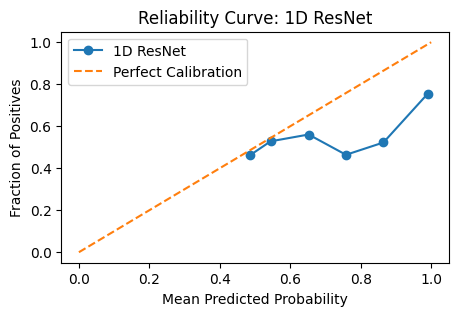

[Robustness] ROC-AUC on Noisy Data: 0.5277
[Robustness] Performance Drop: 0.0021


--- Starting Statistical Validation for 1D ResNet (3 Runs) ---
Training Run 1/3...
  -> Run 1 ROC-AUC: 0.5361
Training Run 2/3...
  -> Run 2 ROC-AUC: 0.5352
Training Run 3/3...
  -> Run 3 ROC-AUC: 0.5173

STATISTICAL VALIDATION RESULTS: 1D ResNet
Mean ROC-AUC: 0.5295
Standard Deviation: 0.0086
95% Confidence Interval: [0.5033, 0.5558]


In [24]:
from tensorflow.keras.layers import Add

def build_resnet():
    input_np = Input(shape=(X_train_np.shape[1],), name="tabular_input")
    input_seq = Input(shape=(X_train_seq.shape[1], 1), name="sequence_input")

    x1 = Dense(128, activation='relu')(input_np)
    x1 = BatchNormalization()(x1)

    x2 = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(input_seq)
    x2 = BatchNormalization()(x2)

    res1 = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(x2)
    res1 = BatchNormalization()(res1)
    res1 = Conv1D(filters=64, kernel_size=3, padding='same', activation=None)(res1)
    x2 = Add()([x2, res1]) # Skip connection
    x2 = keras.layers.Activation('relu')(x2)
    x2 = BatchNormalization()(x2)

    res2 = Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(x2)
    res2 = BatchNormalization()(res2)
    res2 = Conv1D(filters=32, kernel_size=3, padding='same', activation=None)(res2)
    x2_shortcut = Conv1D(filters=32, kernel_size=1, padding='same')(x2) # Dimension matching
    x2 = Add()([x2_shortcut, res2]) # Skip connection
    x2 = keras.layers.Activation('relu')(x2)
    x2 = Flatten()(x2)

    merged = Concatenate()([x1, x2])
    merged = Dense(64, activation='relu')(merged)
    merged = Dropout(0.3)(merged)
    output = Dense(1, activation='sigmoid')(merged)

    model = Model(inputs=[input_np, input_seq], outputs=output)
    optimizer = keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy', keras.metrics.AUC(name='auc')])
    return model

# Train once
model_resnet = build_resnet()
model_resnet.fit([X_train_np, X_train_seq], y_train, validation_split=0.1, epochs=20, batch_size=64, verbose=1)

# Analyze
evaluate_dl_model("1D ResNet", model_resnet, X_test_np, X_test_seq, y_test)

# Validate Statistically
statistical_validation_run("1D ResNet", build_resnet, [X_train_np, X_train_seq], y_train, epochs=15, runs=3)